In [29]:
import osmnx as ox
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pandas as pd
import seaborn as sns
import os

In [30]:
plt.rcParams.update({
    'font.size': 20,  # 默认字体大小
    'font.family': 'Arial',
    'axes.labelsize': 24,  # 设置 xlabel 和 ylabel 的默认字体大小
    'axes.labelpad': 10
})
bbox_style = dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3')

In [31]:
def fit_line(x, y):
    """Fit a line to the data and return slope and intercept."""
    m, c = np.polyfit(x, y, 1)
    return m, c

def calculate_rmse(y_true, y_pred):
    """Calculate Root Mean Square Error."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def calculate_r2(y_true, y_pred):
    """Calculate R-squared."""
    import sklearn.metrics as metrics
    return metrics.r2_score(y_true, y_pred)

def calculate_mae(y_true, y_pred):
    """Calculate Mean Absolute Error."""
    return np.mean(np.abs(y_true - y_pred))

# node-level visualization and metrics calculation for NYC area

In [32]:
sampled_nodes_full  = pd.read_csv('NYC_sampled_nodes.csv')

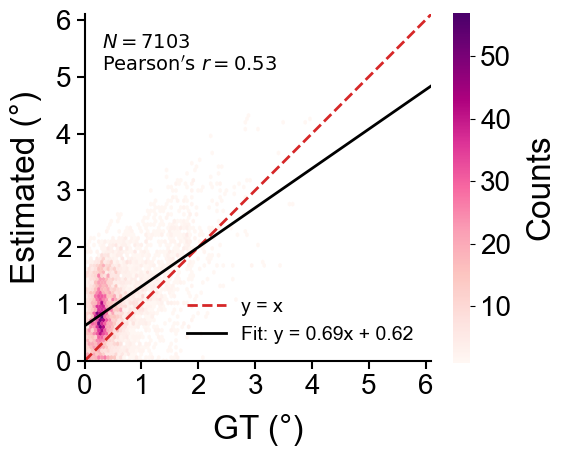

In [33]:
fig, ax = plt.subplots(figsize=(6, 6))

x = sampled_nodes_full['GT'].values
y = sampled_nodes_full['post_huber'].values
N = len(x)

# 2D histogram as density
h = ax.hexbin(
    x, y,
    gridsize=100,
    cmap='RdPu',
    mincnt=1,
    linewidths=0.2,
    reduce_C_function=np.sum
)
# 创建 colorbar
cb = fig.colorbar(h, ax=ax, pad=0.05, shrink=0.7)
cb.set_label('Counts')


# ensure ticks formatted nicely (optional), and reduce the number of ticks
# cb.ax.set_yticklabels([f"{int(v)}" for v in cb.get_ticks()])

# only select the ticks that are integers and no decimals
cb.ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=6))

cb.outline.set_visible(False)



# Diagonal reference line
ax.plot([0, 10], [0, 10],
        color='#d62728',
        linestyle='--',
        linewidth=2,
        label='y = x')

# Fitted regression line
m, c = fit_line(x,
                y)
ax.plot([0, 10],
        [c, m * 10 + c],
        color="#000000",
        linestyle='-',
        linewidth=2,
        label=f'Fit: y = {m:.2f}x + {c:.2f}')

# Metrics annotation
r = np.corrcoef(x, y)[0, 1]
# metrics_text = f'RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nN: {N}'
metrics_text = fr"$N={N}$" + "\n" + fr"$\mathrm{{Pearson's}}\ r={r:.2f}$"
ax.text(0.3, 0.85*6, metrics_text, color='black', fontsize=14)

ax.set_xlabel('GT (°)')
ax.set_ylabel('Estimated (°)')
ax.set_xticks(np.arange(0, 11, 1))
ax.set_yticks(np.arange(0, 11, 1))
ax.set_xlim(0, 6.1)
ax.set_ylim(0, 6.1)
ax.set_aspect('equal', adjustable='box')

ax.legend(frameon=False, loc='lower right', fontsize=14)

# delete the xgrid
# ax.grid(axis='y', linestyle=':', alpha=0.5)

# delete the top and right spines
ax.spines['top'].set_visible(False)     
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)  # 设置左边框线宽
ax.spines['bottom'].set_linewidth(1.5)  # 设置下边

# ticks length
ax.tick_params(axis='both', which='major', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', length=3, width=1)

plt.tight_layout()

plt.show()

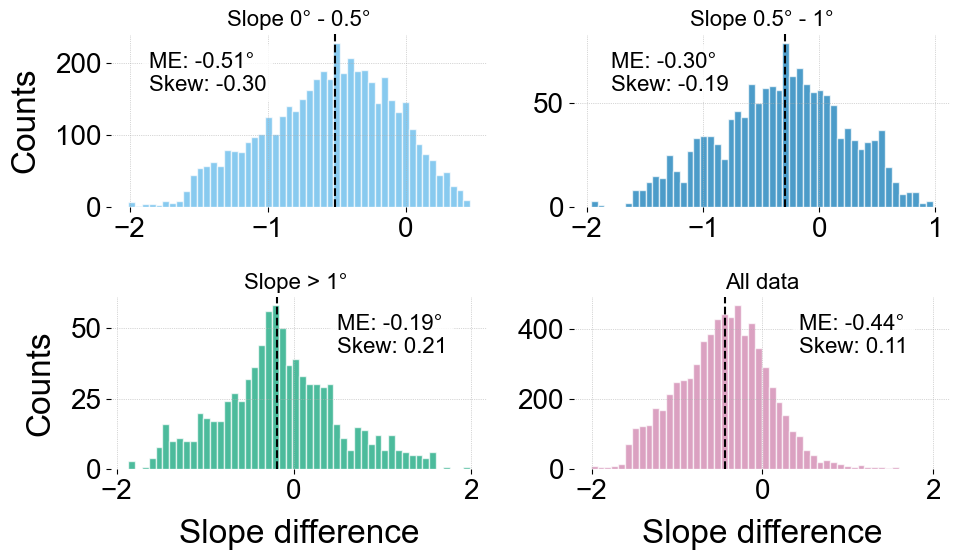

In [34]:
colors = ['#56B4E9','#0072B2','#009E73','#CC79A7']
# plot histogram for 4 different slope ranges
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
slope_ranges = [(0, 0.5), (0.5, 1), (1, 10)]
titles = ['Slope 0° - 0.5°', 'Slope 0.5° - 1°', 'Slope > 1° ']

for i, (ax, slope_range, title) in enumerate(zip(axs.flatten()[:3], slope_ranges, titles)):
    slope_min, slope_max = slope_range
    data_subset = sampled_nodes_full[(sampled_nodes_full['GT'] >= slope_min) & (sampled_nodes_full['GT'] < slope_max)]

    ax.hist(data_subset['slope_diff_huber'], bins=50, color=colors[i], edgecolor='white', alpha=0.7)
    ax.set_title(title, fontsize=16)
    # ax.set_xlabel('Slope difference (deg)')
    # ax.set_ylabel('Frequency')
    
    # Calculate metrics
    median_val = data_subset['slope_diff_huber'].median()
    skewness_val = data_subset['slope_diff_huber'].skew()
    # Add median line
    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.5)
    
    # Add metrics text in upper left corner
    metrics_text = f'ME: {median_val:.2f}°'
    skew_text = f'Skew: {skewness_val:.2f}'
    metrics_text += f'\n{skew_text}'
    if median_val < 0 and skewness_val > 0:
        ax.text(0.6, 0.9, metrics_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
            fontsize=16)
    else:

        ax.text(0.1, 0.9, metrics_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
            fontsize=16)

# All data in axs[1,1]
all_data = sampled_nodes_full['slope_diff_huber']
axs[1, 1].hist(all_data, bins=50, color=colors[3], edgecolor='white', alpha=0.7)
axs[1, 1].set_title('All data', fontsize=16)
# axs[1, 1].set_xlabel('Slope difference (deg)')
# axs[1, 1].set_ylabel('Frequency')

# Calculate metrics for all data
median_all = all_data.median()
skewness_all = all_data.skew()

# Add median line for all data
axs[1, 1].axvline(median_all, color='black', linestyle='--', linewidth=1.5)

# Add metrics text for all data
metrics_text_all = f'ME: {median_all:.2f}°\nSkew: {skewness_all:.2f}'
if median_all < 0 and skewness_all > 0:
    axs[1, 1].text(0.6, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
               verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
               fontsize=16)
else:
    axs[1, 1].text(0.1, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
               verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
               fontsize=16)

# set y title for the left two plots  
axs[0, 0].set_ylabel('Counts')
axs[1, 0].set_ylabel('Counts')
# set x title for the bottom two plots
axs[1, 0].set_xlabel('Slope difference')
axs[1, 1].set_xlabel('Slope difference')
for ax in axs.flatten():
    ax.grid(True, alpha=1, linewidth=0.5, linestyle=':')
    #delete the y grid lines

    # delete the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()

In [35]:
from scipy import stats

# calculate the performance metrics among different groups
rmse, mae, N, smape = {}, {}, {}, {}

# Define slope ranges and corresponding labels
slope_ranges = [(0, 0.5), (0.5, 1.0), (1.0, 10.0)]
range_labels = [f"{a:g} - {b:g}°" for a, b in slope_ranges]

# Add overall dataset
all_ranges = [(-np.inf, np.inf)] + slope_ranges
all_labels = ['All'] + range_labels

for i, (slope_min, slope_max) in enumerate(all_ranges):
    label = all_labels[i]

    # Filter data for this slope range
    if slope_min == -np.inf:
        mask = sampled_nodes_full['GT'].notna()
    else:
        mask = ((sampled_nodes_full['GT'] >= slope_min) & 
                (sampled_nodes_full['GT'] < slope_max))

    subset = sampled_nodes_full[mask]
    # Count the number of samples in this range
    N[label] = sampled_nodes_full[mask].shape[0]
    if len(subset) == 0:
        continue
    
    # Get ground truth and predictions
    y_true = subset['GT'].values
    y_pred = subset['post_huber'].values

    # Calculate metrics
    rmse[label] = calculate_rmse(y_true, y_pred)
    mae[label] = calculate_mae(y_true, y_pred)
    smape[label] = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

# Display results
metrics_df = pd.DataFrame({
    'RMSE': rmse,
    'MAE': mae,
    'N': N,
    'sMAPE (%)': smape
})

print("Performance Metrics by Slope Range:")
print(metrics_df.round(3))

Performance Metrics by Slope Range:
           RMSE    MAE     N  sMAPE (%)
All       0.705  0.570  7103     85.088
0 - 0.5°  0.727  0.593  4763    101.576
0.5 - 1°  0.635  0.506  1478     59.829
1 - 10°   0.696  0.549   862     37.293


# edge-level slope visualization & metrics calculation for NYC area

In [36]:
selected_grouped_edges = pd.read_csv('NYC_sampled_edges_full.csv')

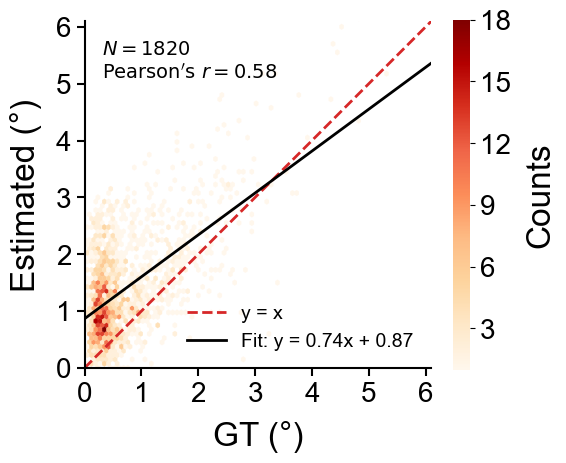

In [37]:
fig, ax = plt.subplots(figsize=(6, 6))

x = selected_grouped_edges['GT'].values
y = selected_grouped_edges['post_huber'].values
N = len(x)

# 2D histogram as density
h = ax.hexbin(
    x, y,
    gridsize=75,
    cmap='OrRd',
    mincnt=1,
    linewidths=0.2,
    reduce_C_function=np.sum
)
cb = fig.colorbar(h, ax=ax, pad=0.05, shrink=0.7)
cb.set_label('Counts')


# only select the ticks that are integers and no decimals
cb.ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=6))

# delete the box of the colorbar
cb.outline.set_visible(False)


# Diagonal reference line
ax.plot([0, 10], [0, 10],
        color='#d62728',
        linestyle='--',
        linewidth=2,
        label='y = x')

# Fitted regression line
m, c = fit_line(x,
                y)
ax.plot([0, 10],
        [c, m * 10 + c],
        color="#000000",
        linestyle='-',
        linewidth=2,
        label=f'Fit: y = {m:.2f}x + {c:.2f}')

person_r = stats.pearsonr(y, x)[0]
metrics_text = fr"$N={N}$" + "\n" + fr"$\mathrm{{Pearson's}}\ r={person_r:.2f}$"
ax.text(0.3, 0.85*6, metrics_text, color='black', fontsize=14)

ax.set_xlabel('GT (°)')
ax.set_ylabel('Estimated (°)')
ax.set_xticks(np.arange(0, 11, 1))
ax.set_yticks(np.arange(0, 11, 1))
ax.set_xlim(0, 6.1)
ax.set_ylim(0, 6.1)

ax.legend(frameon=False, loc='lower right', fontsize=14)
ax.set_aspect('equal', adjustable='box')

# delete the xgrid
# ax.grid(axis='y', linestyle=':', alpha=0.5)

# delete the top and right spines
ax.spines['top'].set_visible(False)     
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)  # 设置左边框线宽
ax.spines['bottom'].set_linewidth(1.5)  # 设置下边

# ticks length
ax.tick_params(axis='both', which='major', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', length=3, width=1)

plt.tight_layout()
plt.show()

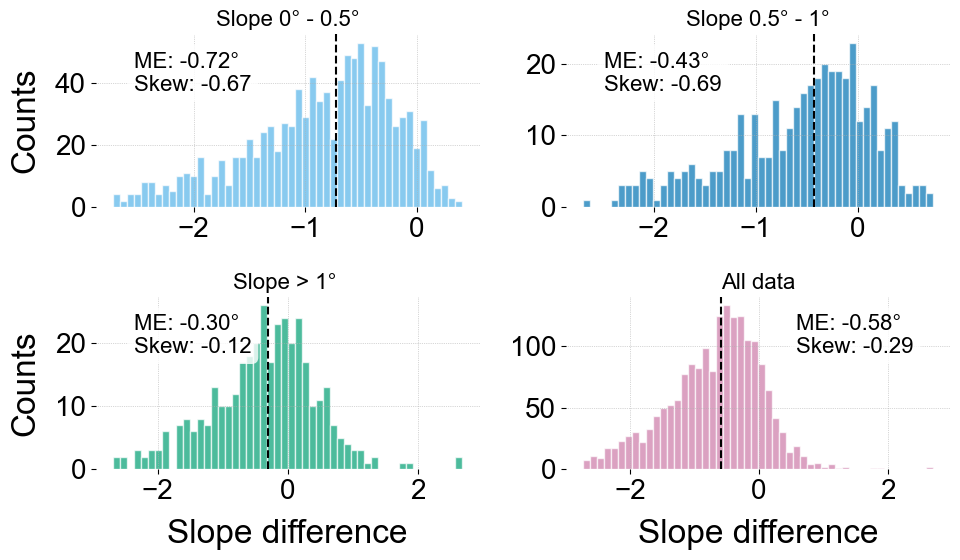

In [38]:
colors = ['#56B4E9','#0072B2','#009E73','#CC79A7']
# plot histogram for 4 different slope ranges
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
slope_ranges = [(0, 0.5), (0.5, 1), (1, 10)]
titles = ['Slope 0° - 0.5°', 'Slope 0.5° - 1°', 'Slope > 1° ']
df = selected_grouped_edges

for i, (ax, slope_range, title) in enumerate(zip(axs.flatten()[:3], slope_ranges, titles)):
    slope_min, slope_max = slope_range
    data_subset = df[(df['GT'] >= slope_min) & (df['GT'] < slope_max)]

    ax.hist(data_subset['slope_diff_huber'], bins=50, color=colors[i], edgecolor='white', alpha=0.7)
    ax.set_title(title, fontsize=16)
    # ax.set_xlabel('Slope difference (deg)')
    # ax.set_ylabel('Frequency')
    
    # Calculate metrics
    median_val = data_subset['slope_diff_huber'].median()
    skewness_val = data_subset['slope_diff_huber'].skew()
    # Add median line
    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.5)
    
    # Add metrics text in upper left corner
    metrics_text = f'ME: {median_val:.2f}°\nSkew: {skewness_val:.2f}'
    if median_val < 0 and skewness_val > 0:
        ax.text(0.6, 0.9, metrics_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
            fontsize=16)
    else:
        ax.text(0.1, 0.9, metrics_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
                fontsize=16)

# All data in axs[1,1]
all_data = df['slope_diff_huber']
axs[1, 1].hist(all_data, bins=50, color=colors[3], edgecolor='white', alpha=0.7)
axs[1, 1].set_title('All data', fontsize=16)
# axs[1, 1].set_xlabel('Slope difference (deg)')
# axs[1, 1].set_ylabel('Frequency')

# Calculate metrics for all data
median_all = all_data.median()
skewness_all = all_data.skew()

# Add median line for all data
axs[1, 1].axvline(median_all, color='black', linestyle='--', linewidth=1.5)

# Add metrics text for all data
metrics_text_all = f'ME: {median_all:.2f}°\nSkew: {skewness_all:.2f}'
axs[1, 1].text(0.6, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
               verticalalignment='top', horizontalalignment='left', bbox=bbox_style,
               fontsize=16)

# set y title for the left two plots  
axs[0, 0].set_ylabel('Counts')
axs[1, 0].set_ylabel('Counts')
# set x title for the bottom two plots
axs[1, 0].set_xlabel('Slope difference')
axs[1, 1].set_xlabel('Slope difference')
for ax in axs.flatten():
    ax.grid(True, alpha=1, linewidth=0.5, linestyle=':')
    #delete the y grid lines

    # delete the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()

In [39]:
# calculate the slope difference metrics among different groups
rmse, mae, N,  smape = {}, {}, {}, {}
# Define slope ranges and corresponding labels
slope_ranges = [(0, 0.5), (0.5, 1.0), (1.0, 10.0)]
range_labels = [f"{a:g} - {b:g}°" for a, b in slope_ranges]
# Add overall dataset
all_ranges = [(-np.inf, np.inf)] + slope_ranges
all_labels = ['All'] + range_labels
for i, (slope_min, slope_max) in enumerate(all_ranges):
    label = all_labels[i]

    # Filter data for this slope range
    if slope_min == -np.inf:
        mask = selected_grouped_edges['GT'].notna()
    else:
        mask = ((selected_grouped_edges['GT'] >= slope_min) & 
                (selected_grouped_edges['GT'] < slope_max))

    subset = selected_grouped_edges[mask]
    # Count the number of samples in this range
    N[label] = selected_grouped_edges[mask].shape[0]
    if len(subset) == 0:
        continue
    
    # Get ground truth and predictions
    y_true = subset['GT'].values
    y_pred = subset['post_huber'].values

    # Calculate metrics
    rmse[label] = calculate_rmse(y_true, y_pred)
    mae[label] = calculate_mae(y_true, y_pred)

    smape[label] = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

# Display results
metrics_df = pd.DataFrame({
    'RMSE': rmse,
    'MAE': mae,
    'sMAPE (%)': smape,
    'N': N
})
print("Performance Metrics by Slope Range (Grouped by Edge):")
print(metrics_df.round(3))

Performance Metrics by Slope Range (Grouped by Edge):
           RMSE    MAE  sMAPE (%)     N
All       0.996  0.781     82.928  1820
0 - 0.5°  1.067  0.862    108.538  1043
0.5 - 1°  0.895  0.669     60.900   406
1 - 10°   0.892  0.674     35.036   371


# edge-level relief visualization & metrics calculation for NYC area

In [40]:
selected_grouped_edges_elev = pd.read_csv('NYC_sampled_edges_full_relief.csv')

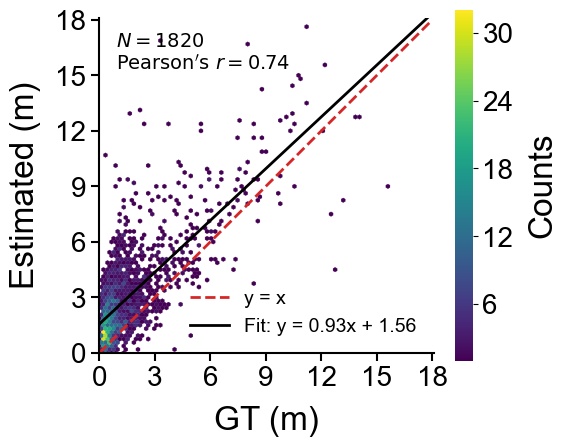

In [41]:
fig, ax = plt.subplots(figsize=(6, 6))

x = selected_grouped_edges_elev['GT_elev'].values
y = selected_grouped_edges_elev['post_huber_elev'].values
N = len(x)

# 2D histogram as density
h = ax.hexbin(
    x, y,
    gridsize=150,
    cmap='viridis',
    mincnt=1,
    linewidths=0.2,
    reduce_C_function=np.sum
)
cb = fig.colorbar(h, ax=ax, pad=0.05, shrink=0.7)
cb.set_label('Counts')

# Use MaxNLocator to automatically set integer ticks
cb.ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=6))

# delete the box of the colorbar
cb.outline.set_visible(False)


# Diagonal reference line
ax.plot([0, 18], [0, 18],
        color='#d62728',
        linestyle='--',
        linewidth=2,
        label='y = x')

# Fitted regression line
m, c = fit_line(x,
                y)
ax.plot([0, 18],
        [c, m * 18 + c],
        color="#000000",
        linestyle='-',
        linewidth=2,
        label=f'Fit: y = {m:.2f}x + {c:.2f}')

person_r = stats.pearsonr(y, x)[0]
metrics_text = fr"$N={N}$" + "\n" + fr"$\mathrm{{Pearson's}}\ r={person_r:.2f}$"
ax.text(0.9, 0.85*18, metrics_text, color='black', fontsize=14)

ax.set_xlabel('GT (m)')
ax.set_ylabel('Estimated (m)')
ax.set_xticks(np.arange(0, 19, 3))
ax.set_yticks(np.arange(0, 19, 3))
ax.set_xlim(0, 18.1)
ax.set_ylim(0, 18.1)

ax.legend(frameon=False, loc='lower right', fontsize=14)
ax.set_aspect('equal', 'box')

# delete the xgrid
# ax.grid(axis='y', linestyle=':', alpha=0.5)

# delete the top and right spines
ax.spines['top'].set_visible(False)     
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)  # 设置左边框线宽
ax.spines['bottom'].set_linewidth(1.5)  # 设置下边

# ticks length
ax.tick_params(axis='both', which='major', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', length=3, width=1)

plt.tight_layout()
plt.show()

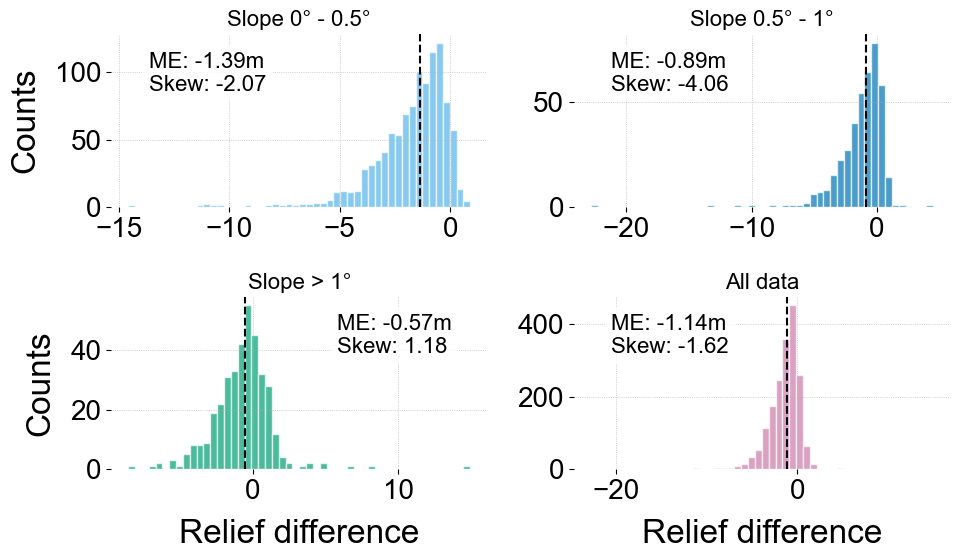

In [42]:
colors = ['#56B4E9','#0072B2','#009E73','#CC79A7']
# plot histogram for 4 different slope ranges
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
slope_ranges = [(0, 0.5), (0.5, 1), (1, 10)]
titles = ['Slope 0° - 0.5°', 'Slope 0.5° - 1°', 'Slope > 1°']
df = selected_grouped_edges_elev

for i, (ax, slope_range, title) in enumerate(zip(axs.flatten()[:3], slope_ranges, titles)):
    slope_min, slope_max = slope_range
    data_subset = df[(df['GT'] >= slope_min) & (df['GT'] < slope_max)]

    ax.hist(data_subset['slope_diff_huber_elev'], bins=50, color=colors[i], edgecolor='white', alpha=0.7)
    ax.set_title(title, fontsize=16)
    
    # Calculate metrics
    median_val = data_subset['slope_diff_huber_elev'].median()
    skewness_val = data_subset['slope_diff_huber_elev'].skew()

    # Add median line
    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.5)
    
    # Add metrics text in upper left corner
    metrics_text = f'ME: {median_val:.2f}m\nSkew: {skewness_val:.2f}'
    if median_val < 0 and skewness_val > 0:
        ax.text(0.6, 0.9, metrics_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='left',
            fontsize=16, bbox=bbox_style)
    else:
        ax.text(0.1, 0.9, metrics_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='left',
            fontsize=16, bbox=bbox_style)

# All data in axs[1,1]
all_data = df['slope_diff_huber_elev']
axs[1, 1].hist(all_data, bins=50, color=colors[3], edgecolor='white', alpha=0.7)
axs[1, 1].set_title('All data', fontsize=16)

# Calculate metrics for all data
median_all = all_data.median()
skewness_all = all_data.skew()

# Add median line for all data
axs[1, 1].axvline(median_all, color='black', linestyle='--', linewidth=1.5)

# Add metrics text for all data
metrics_text_all = f'ME: {median_all:.2f}m\nSkew: {skewness_all:.2f}'

axs[1, 1].text(0.1, 0.9, metrics_text_all, transform=axs[1, 1].transAxes,
               verticalalignment='top', horizontalalignment='left',
               fontsize=16, bbox=bbox_style)

# set y title for the left two plots  
axs[0, 0].set_ylabel('Counts')
axs[1, 0].set_ylabel('Counts')
# set x title for the bottom two plots
axs[1, 0].set_xlabel('Relief difference')
axs[1, 1].set_xlabel('Relief difference')
for ax in axs.flatten():
    ax.grid(True, alpha=1, linewidth=0.5, linestyle=':')

    # delete the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()

In [43]:
import scipy.stats as stats
# slope difference metrics among different groups
rmse, mae,  N, smape = {}, {}, {}, {}
# Define slope ranges and corresponding labels
slope_ranges = [(0, 0.5), (0.5, 1.0), (1.0, 10.0)]
range_labels = [f"{a:g} - {b:g}°" for a, b in slope_ranges]
# Add overall dataset
all_ranges = [(-np.inf, np.inf)] + slope_ranges
all_labels = ['All'] + range_labels
for i, (slope_min, slope_max) in enumerate(all_ranges):
    label = all_labels[i]

    # Filter data for this slope range
    if slope_min == -np.inf:
        mask = selected_grouped_edges_elev['GT'].notna()
    else:
        mask = ((selected_grouped_edges_elev['GT'] >= slope_min) & 
                (selected_grouped_edges_elev['GT'] < slope_max))

    subset = selected_grouped_edges_elev[mask]
    # Count the number of samples in this range
    N[label] = selected_grouped_edges_elev[mask].shape[0]
    if len(subset) == 0:
        continue
    
    # Get ground truth and predictions
    y_true = subset['GT_elev'].values
    y_pred = subset['post_huber_elev'].values

    # Calculate metrics
    rmse[label] = calculate_rmse(y_true, y_pred)
    mae[label] = calculate_mae(y_true, y_pred)
    smape[label] = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100
   
# Display results
metrics_df = pd.DataFrame({
    'RMSE (m)': rmse,
    'MAE (m)': mae,
    'sMAPE (%)': smape,
    'N': N
})
print("Performance Metrics by Slope Range (Grouped by Edge) - Elevation Difference:")
print(metrics_df.round(3))

Performance Metrics by Slope Range (Grouped by Edge) - Elevation Difference:
          RMSE (m)  MAE (m)  sMAPE (%)     N
All          2.364    1.658     82.941  1820
0 - 0.5°     2.402    1.781    108.547  1043
0.5 - 1°     2.457    1.512     60.913   406
1 - 10°      2.142    1.468     35.065   371
